# Hypothesis testing 

Hypothesis testing is a group of statistical inferences to compare date between different groups. Typically, the impact of a categorical independent variable on a continuous dependent variable is evaluated. 

For example, we could ask whether the 3 Penguin species in the Palmer Penguin dataset have significantly different body weights. 

## Learning Goals


In [1]:
# we import the pandas library 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats



## Loading the dataset

As before, we are loading the dataset into a _pandas_ dataframe. 

In [2]:
df_penguins = pd.read_csv('../../W4_Pandas_And_Environmental_Data/Data/palmer_penguin_data.csv',
                          sep = ',',
                          na_values='NA',
                          skiprows= 1,
                          index_col=0   # Use the first column as the index of the DataFrame
                          )
df_penguins

df_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
rowid,,,,,,,,
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Looking at means and standard deviations we can see that Adelie pinguins appear to have a shorter bill compared to Chinstrap and Gentoo, while Gentoo penguins appear to be heaver than the other two species.   

In [3]:
columns = ['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
print('Mean Values')
print(df_penguins[columns].groupby(by='species').mean())
print('Standard Deviation')
print(df_penguins[columns].groupby(by='species').std())

Mean Values
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie          38.791391      18.346358         189.953642  3700.662252
Chinstrap       48.833824      18.420588         195.823529  3733.088235
Gentoo          47.504878      14.982114         217.186992  5076.016260
Standard Deviation
           bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
species                                                                 
Adelie           2.663405       1.216650           6.539457   458.566126
Chinstrap        3.339256       1.135395           7.131894   384.335081
Gentoo           3.081857       0.981220           6.484976   504.116237


For the analysis we are splitting the data into separate dataframes

In [4]:
df_Adelie = df_penguins.loc[df_penguins.species == 'Adelie']
df_Gentoo = df_penguins.loc[df_penguins.species == 'Gentoo']
df_Chinstrap = df_penguins.loc[df_penguins.species == 'Chinstrap']

We can also visualize this data using histograms and boxplots.

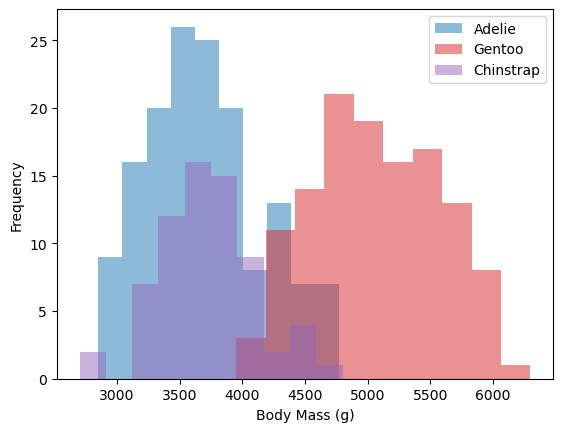

In [5]:
import matplotlib.pyplot as plt
fix,ax = plt.subplots()
df_Adelie.plot(kind='hist', y = 'body_mass_g', color = 'tab:blue', alpha = 0.5, ax =ax )
df_Gentoo.plot(kind='hist', y = 'body_mass_g', color = 'tab:red', alpha = 0.5, ax =ax )
df_Chinstrap.plot(kind='hist', y = 'body_mass_g', color = 'tab:purple', alpha = 0.5, ax =ax)
plt.xlabel('Body Mass (g)')
plt.legend(['Adelie', 'Gentoo', 'Chinstrap'])

Boxplots are another way of visualizing the distribution of data. They show the median, inter-quartile range, and outliers.

bill_length_mm          Axes(0.125,0.11;0.352273x0.77)
flipper_length_mm    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

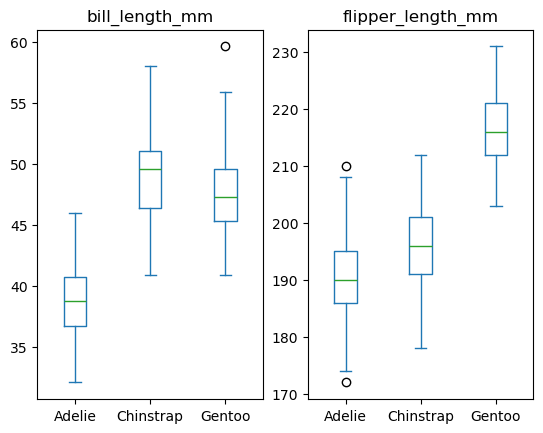

In [8]:
df_penguins.plot(kind = 'box', column = ['bill_length_mm',  'flipper_length_mm'], by = 'species')


## The T-test

If we want to compare two groups and have limited data, we would apply the T-test. 

The `scipy.stats` package has the `ttest_ind()`-method for T-tests with independent samples. There is also a paired T-test, when samples are not independent. 

We can apply this using a two-sided test (which tests for the difference but not the direction).

In [10]:
import scipy.stats

x = df_Adelie['body_mass_g']
y = df_Gentoo['body_mass_g']

scipy.stats.ttest_ind(x, y, nan_policy = 'omit', alternative='two-sided', equal_var = False)

TtestResult(statistic=np.float64(-23.38602766996551), pvalue=np.float64(7.709823145147335e-65), df=np.float64(249.64255363131144))

The results show a very small p-value, meaning that we have high confidence that Gentoo and Adelie penguins have different body weights. This tracks with our observation. 

## ANOVA

If we want to compare more than two groups, we have to apply the ANOVA test. Repeating T-tests for multiple groups can lead to overestimations of the differences due to the simple 1:1 comparison. 

ANOVA allows us to simultaneously test several groups. 

In this case we can use the `statsmodels` package to build a simple linear model that relates the target variable (`body_mass_g`) to the category (`species`). 


In [13]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

data = df_penguins.dropna()

model = ols('body_mass_g ~ C(species)', data=data).fit()
anova_table = sm.stats.anova_lm(model, typ=2)  # the typ arguments specifies whether to include interaction effects (type 1) or not (type 2).
print(anova_table)

                  sum_sq     df           F        PR(>F)
C(species)  1.451902e+08    2.0  341.894895  3.744505e-81
Residual    7.006945e+07  330.0         NaN           NaN


As expected, we reject the null hypothesis that all species have the same body mass. At least one of the species is different. 

We can now perform a post-hoc test to evaluate each pair. 

In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=data['body_mass_g'],   # Data values
                          groups=data['species'], # Group labels
                          alpha=0.05)  

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower     upper   reject
---------------------------------------------------------------
   Adelie Chinstrap   26.9239 0.9164 -132.3528  186.2005  False
   Adelie    Gentoo 1386.2726    0.0 1252.2897 1520.2554   True
Chinstrap    Gentoo 1359.3487    0.0 1194.4304 1524.2671   True
---------------------------------------------------------------


The test results show that Chinstrap is different from Adelie and Gentoo, while Gentoo and Adelie are similar to each other. Which is exactly what we assumed from the boxplot. 